# 03. Fee, Barrier 및 Dual-path 확정 라벨 (Legacy 지정가)

> **사용 중단:** 이 notebook은 `close-1tick` 지정가와 NO_FILL을 가정한 과거 비교용이다. 현재 primary는 즉시체결이며 `09_immediate_fill_rebaseline.ipynb`를 사용한다.

연속 60봉 판단 시점에 대해 진입 주문, 수수료, TP +5% / SL -3% barrier와 두 가지 OHLC 내부 경로를 적용해 10분 단타 확정/ambiguous 라벨을 생성한다.

V1 라벨 경로:

```text
high-first: Open → High → Low → Close
low-first:  Open → Low → High → Close
```

두 경로 결과가 같으면 확정 라벨, 다르면 `AMBIGUOUS`로 저장한다. ambiguous를 임의로 positive/negative로 변환하지 않는다.

> 이 notebook의 수수료는 모델 개발용 baseline이다. 실제 고객 부과 수수료와 반올림은 Toss 거래명세서로 다시 확인해야 한다.

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from decimal import Decimal, ROUND_CEILING, ROUND_FLOOR, ROUND_HALF_UP
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 120)
plt.style.use("seaborn-v0_8-whitegrid") if "seaborn-v0_8-whitegrid" in plt.style.available else None
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Noto Sans CJK KR", "Noto Sans CJK JP"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False


## 1. 경로와 V1 설정

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "AGENT.md").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = (PROJECT_ROOT / "../../data/stock_data").resolve()
RAW_ROOT = DATA_ROOT / "raw"
ENRICHED_PATHS = sorted(RAW_ROOT.glob("session_*/*_enriched.csv"))

SEQUENCE_LENGTH = 60
FEATURE_WARMUP_ROWS = 60  # 02 notebook의 rolling_std_return_60 최초 유효 위치
MIN_DECISION_POSITION = FEATURE_WARMUP_ROWS + SEQUENCE_LENGTH - 1
HORIZONS = [10]
PRIMARY_HORIZON = 10
MAX_HORIZON = max(HORIZONS)

SPLIT_BY_SESSION = {
    "session_2026-07-07": "train",
    "session_2026-07-08": "train",
    "session_2026-07-09": "train",
    "session_2026-07-10": "train",
    "session_2026-07-13": "validation",
    "session_2026-07-14": "validation",
    "session_2026-07-15": "test",
    "session_2026-07-16": "test",
    "session_2026-07-17": "test",
}

assert ENRICHED_PATHS
assert {path.parent.name for path in ENRICHED_PATHS} <= set(SPLIT_BY_SESSION)
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"enriched files: {len(ENRICHED_PATHS):,}")
print(f"minimum decision position in a continuous run: {MIN_DECISION_POSITION}")


PROJECT_ROOT: /home/user/urbandatalab/YSLee/code/Detecting-entry-signals-for-short-term-trades-right-before-a-rapid-price-surge
enriched files: 208
minimum decision position in a continuous run: 119


### Baseline 거래 가정

```text
주문 금액         = $1,000
진입 지정가       = floor_to_tick(close_t - 1 tick)
체결 조건         = 첫 미래 1분봉에서 지정가보다 1 tick 아래까지 관통
체결 가격         = 진입 지정가 (보수적 가정)
tick size         = 기준가 $1 미만 $0.0001, $1 이상 $0.01
TP / SL           = +5.0% / -3.0%
매도 슬리피지     = 0.1%
horizon           = 10분 고정
미래 gap          = 라벨 대상에서 제외
```

가격대별 tick size는 Rule 612 기준의 학습용 proxy이며 실제 Toss 주문 단위가 확인되면 교체한다: [SEC Rule 612 FAQ](https://www.sec.gov/divisions/marketreg/subpenny612faq.htm). tick size는 체결 라벨의 가격 양자화에만 쓰고 모델 feature에는 넣지 않는다.

SEC Section 31 비율은 2026-04-04부터 매도대금 백만 달러당 $20.60이다: [SEC FY2026 advisory](https://www.sec.gov/rules-regulations/fee-rate-advisories/2026-2). 2026 FINRA TAF는 주당 $0.000195, 거래당 최대 $9.79이다: [FINRA fee schedule](https://www.finra.org/rules-guidance/rule-filings/sr-finra-2024-019/fee-adjustment-schedule).

In [3]:
D = Decimal
CENT = D("0.01")

@dataclass(frozen=True)
class TradingConfig:
    order_notional_usd: Decimal = D("1000.00")
    tick_size_below_one: Decimal = D("0.0001")
    tick_size_at_or_above_one: Decimal = D("0.01")
    take_profit_pct: Decimal = D("0.05")
    stop_loss_pct: Decimal = D("0.03")
    sell_slippage_pct: Decimal = D("0.001")
    buy_commission_rate: Decimal = D("0.001")
    sell_commission_rate: Decimal = D("0.001")
    sec_fee_rate: Decimal = D("0.0000206")
    taf_per_share: Decimal = D("0.000195")
    taf_max_per_trade: Decimal = D("9.79")

CONFIG = TradingConfig()
assert HORIZONS == [10] and PRIMARY_HORIZON == 10 and MAX_HORIZON == 10
assert CONFIG.take_profit_pct == D("0.05") and CONFIG.stop_loss_pct == D("0.03")
display(pd.Series({key: str(value) for key, value in asdict(CONFIG).items()}, name="value").to_frame())


,value
order_notional_usd,1000.00
tick_size_below_one,0.0001
tick_size_at_or_above_one,0.01
take_profit_pct,0.05
stop_loss_pct,0.03
sell_slippage_pct,0.001
buy_commission_rate,0.001
sell_commission_rate,0.001
sec_fee_rate,0.0000206
taf_per_share,0.000195


## 2. Decimal 수수료 및 주문 함수

FINRA는 회원사 TAF를 집계 단위로 산출하므로 고객 거래별 반올림을 규정하지 않는다. 여기서는 `AGENT.md`의 baseline대로 commission은 nearest cent, 규제비용은 ceil cent로 계산한다. 실제 브로커 명세서 확보 후 교체한다.

In [4]:
def to_decimal(value) -> Decimal:
    return value if isinstance(value, Decimal) else D(str(value))

def round_cent(value: Decimal) -> Decimal:
    return value.quantize(CENT, rounding=ROUND_HALF_UP)

def ceil_cent(value: Decimal) -> Decimal:
    return value.quantize(CENT, rounding=ROUND_CEILING)

def floor_to_tick(price: Decimal, tick_size: Decimal) -> Decimal:
    return (price / tick_size).to_integral_value(rounding=ROUND_FLOOR) * tick_size

def tick_size_for_price(price: Decimal, config: TradingConfig = CONFIG) -> Decimal:
    return config.tick_size_below_one if price < D("1") else config.tick_size_at_or_above_one

@dataclass(frozen=True)
class OrderSetup:
    reference_price: Decimal
    tick_size: Decimal
    entry_price: Decimal
    fill_threshold: Decimal
    take_profit_price: Decimal
    stop_loss_price: Decimal
    shares: int

def build_order(reference_close, config: TradingConfig = CONFIG) -> OrderSetup | None:
    reference = to_decimal(reference_close)
    tick_size = tick_size_for_price(reference, config)
    entry = floor_to_tick(reference - tick_size, tick_size)
    if entry <= 0:
        return None
    shares = int(config.order_notional_usd // entry)
    if shares < 1:
        return None
    return OrderSetup(
        reference_price=reference,
        tick_size=tick_size,
        entry_price=entry,
        fill_threshold=entry - tick_size,
        take_profit_price=entry * (D("1") + config.take_profit_pct),
        stop_loss_price=entry * (D("1") - config.stop_loss_pct),
        shares=shares,
    )

def calculate_trade_result(entry_price, sell_reference_price, shares: int, config: TradingConfig = CONFIG) -> dict:
    buy_price = to_decimal(entry_price)
    sell_reference = to_decimal(sell_reference_price)
    sell_price = sell_reference * (D("1") - config.sell_slippage_pct)
    share_count = D(shares)
    buy_notional = buy_price * share_count
    sell_notional = sell_price * share_count
    buy_commission = round_cent(buy_notional * config.buy_commission_rate)
    sell_commission = round_cent(sell_notional * config.sell_commission_rate)
    sec_fee = ceil_cent(sell_notional * config.sec_fee_rate)
    taf_fee = ceil_cent(min(share_count * config.taf_per_share, config.taf_max_per_trade))
    total_fees = buy_commission + sell_commission + sec_fee + taf_fee
    gross_pnl = sell_notional - buy_notional
    net_pnl = gross_pnl - total_fees
    invested = buy_notional + buy_commission
    return {
        "sell_fill_price": sell_price,
        "buy_notional": buy_notional,
        "sell_notional": sell_notional,
        "buy_commission": buy_commission,
        "sell_commission": sell_commission,
        "sec_fee": sec_fee,
        "taf_fee": taf_fee,
        "total_fees": total_fees,
        "gross_pnl": gross_pnl,
        "net_pnl": net_pnl,
        "gross_return": gross_pnl / buy_notional,
        "net_return": net_pnl / invested,
    }


In [5]:
# 수수료 및 주문 단위 테스트
assert round_cent(D("1.005")) == D("1.01")
assert ceil_cent(D("0.0001")) == D("0.01")
assert floor_to_tick(D("0.4512"), D("0.0001")) == D("0.4512")
assert ceil_cent(min(D("1000000") * CONFIG.taf_per_share, CONFIG.taf_max_per_trade)) == D("9.79")

test_order = build_order(D("1.2345"))
assert test_order is not None
assert test_order.tick_size == D("0.01")
assert test_order.entry_price == D("1.22")
assert test_order.fill_threshold == D("1.21")
assert test_order.shares == 819
subdollar_order = build_order(D("0.4512"))
assert subdollar_order is not None
assert subdollar_order.tick_size == D("0.0001")
assert subdollar_order.entry_price == D("0.4511")
assert subdollar_order.fill_threshold == D("0.4510")
fee_test = calculate_trade_result(test_order.entry_price, test_order.take_profit_price, test_order.shares)
assert fee_test["net_return"] < fee_test["gross_return"]
assert fee_test["total_fees"] > 0
print("PASS: 주문 가격, share sizing, 수수료 및 TAF 상한 테스트")
display(pd.Series({key: str(value) for key, value in fee_test.items()}, name="value").to_frame())


PASS: 주문 가격, share sizing, 수수료 및 TAF 상한 테스트


,value
sell_fill_price,1.2797190
buy_notional,999.18
sell_notional,1048.0898610
buy_commission,1.00
sell_commission,1.05
sec_fee,0.03
taf_fee,0.16
total_fees,2.24
gross_pnl,48.9098610
net_pnl,46.6698610


## 3. Dual-path barrier evaluator

첫 미래 1분봉에서만 지정가 체결을 허용한다. 지정가보다 한 tick 아래를 지나면 지정가로 체결된 것으로 본다. 체결 전 발생한 TP/SL 가격은 무시하며, 체결 후 처음 교차한 barrier만 기록한다.

In [6]:
def barrier_event_at_price(price: float, take_profit: float, stop_loss: float) -> str | None:
    if price >= take_profit:
        return "TP"
    if price <= stop_loss:
        return "SL"
    return None

def barrier_event_on_segment(start: float, end: float, take_profit: float, stop_loss: float) -> str | None:
    immediate = barrier_event_at_price(start, take_profit, stop_loss)
    if immediate:
        return immediate
    if end > start and end >= take_profit:
        return "TP"
    if end < start and end <= stop_loss:
        return "SL"
    return None

def bar_nodes(bar, path_mode: str) -> list[float]:
    if path_mode == "high_first":
        return [float(bar.open), float(bar.high), float(bar.low), float(bar.close)]
    if path_mode == "low_first":
        return [float(bar.open), float(bar.low), float(bar.high), float(bar.close)]
    raise ValueError(f"unknown path mode: {path_mode}")

def evaluate_path(future_bars: pd.DataFrame, horizon: int, order: OrderSetup, path_mode: str) -> dict:
    entry = float(order.entry_price)
    fill_threshold = float(order.fill_threshold)
    take_profit = float(order.take_profit_price)
    stop_loss = float(order.stop_loss_price)
    filled = False
    current_price = None

    for bar_number, bar in enumerate(future_bars.iloc[:horizon].itertuples(index=False), start=1):
        nodes = bar_nodes(bar, path_mode)

        if filled and current_price is not None:
            event = barrier_event_on_segment(current_price, nodes[0], take_profit, stop_loss)
            if event:
                return {"outcome": event, "exit_reference": take_profit if event == "TP" else stop_loss, "event_bar": bar_number}

        current_price = nodes[0]
        if not filled and bar_number == 1 and current_price <= fill_threshold:
            filled = True
            event = barrier_event_at_price(current_price, take_profit, stop_loss)
            if event:
                return {"outcome": event, "exit_reference": take_profit if event == "TP" else stop_loss, "event_bar": bar_number}

        for target_price in nodes[1:]:
            if not filled:
                if bar_number == 1 and current_price > fill_threshold and target_price <= fill_threshold:
                    filled = True
                    event = barrier_event_at_price(fill_threshold, take_profit, stop_loss)
                    if event:
                        return {"outcome": event, "exit_reference": take_profit if event == "TP" else stop_loss, "event_bar": bar_number}
                    event = barrier_event_on_segment(fill_threshold, target_price, take_profit, stop_loss)
                    if event:
                        return {"outcome": event, "exit_reference": take_profit if event == "TP" else stop_loss, "event_bar": bar_number}
                current_price = target_price
                continue

            event = barrier_event_on_segment(current_price, target_price, take_profit, stop_loss)
            if event:
                return {"outcome": event, "exit_reference": take_profit if event == "TP" else stop_loss, "event_bar": bar_number}
            current_price = target_price

        if bar_number == 1 and not filled:
            return {"outcome": "NO_FILL", "exit_reference": None, "event_bar": None}

    return {"outcome": "TIMEOUT", "exit_reference": float(future_bars.iloc[horizon - 1]["close"]), "event_bar": horizon}

def attach_trade_economics(path_result: dict, order: OrderSetup, config: TradingConfig = CONFIG) -> dict:
    if path_result["outcome"] == "NO_FILL":
        return {**path_result, "gross_return": 0.0, "net_return": 0.0, "net_pnl": 0.0, "total_fees": 0.0}
    trade = calculate_trade_result(order.entry_price, path_result["exit_reference"], order.shares, config)
    return {
        **path_result,
        "gross_return": float(trade["gross_return"]),
        "net_return": float(trade["net_return"]),
        "net_pnl": float(trade["net_pnl"]),
        "total_fees": float(trade["total_fees"]),
    }


In [7]:
# 인공 OHLC로 path와 barrier 순서 검증
synthetic_order = build_order(100.0)
assert synthetic_order is not None

def one_bar(open_, high, low, close) -> pd.DataFrame:
    return pd.DataFrame([{"open": open_, "high": high, "low": low, "close": close}])

ambiguous_bar = one_bar(99.98, 106.00, 96.00, 100.00)
assert evaluate_path(ambiguous_bar, 1, synthetic_order, "high_first")["outcome"] == "TP"
assert evaluate_path(ambiguous_bar, 1, synthetic_order, "low_first")["outcome"] == "SL"

tp_bar = one_bar(99.98, 106.00, 98.00, 101.00)
assert evaluate_path(tp_bar, 1, synthetic_order, "high_first")["outcome"] == "TP"
assert evaluate_path(tp_bar, 1, synthetic_order, "low_first")["outcome"] == "TP"

sl_bar = one_bar(99.98, 103.00, 96.00, 99.00)
assert evaluate_path(sl_bar, 1, synthetic_order, "high_first")["outcome"] == "SL"
assert evaluate_path(sl_bar, 1, synthetic_order, "low_first")["outcome"] == "SL"

no_fill_bar = one_bar(100.00, 101.00, 99.99, 100.50)
assert evaluate_path(no_fill_bar, 1, synthetic_order, "high_first")["outcome"] == "NO_FILL"

timeout_bar = one_bar(99.98, 103.00, 98.00, 100.00)
assert evaluate_path(timeout_bar, 1, synthetic_order, "high_first")["outcome"] == "TIMEOUT"
print("PASS: TP first, SL first, AMBIGUOUS, TIMEOUT, NO_FILL 경로 테스트")


PASS: TP first, SL first, AMBIGUOUS, TIMEOUT, NO_FILL 경로 테스트


## 4. 연속 run과 라벨 가능 판단 시점

02 notebook과 동일하게 1분 초과 gap에서 run을 분리한다. 입력 feature warm-up과 60봉을 확보한 뒤, 추가로 미래 10개 연속봉이 있는 판단 시점만 단타 라벨 대상으로 사용한다.

In [8]:
REQUIRED_COLUMNS = ["symbol", "timestamp_kst", "timestamp_utc", "open", "high", "low", "close"]

def load_price_file(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, usecols=REQUIRED_COLUMNS, encoding="utf-8-sig")
    frame["symbol"] = frame["symbol"].astype(str).str.upper()
    frame["timestamp_utc"] = pd.to_datetime(frame["timestamp_utc"], errors="coerce", utc=True)
    frame["timestamp_kst"] = pd.to_datetime(frame["timestamp_kst"], errors="coerce")
    for column in ["open", "high", "low", "close"]:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame = frame.sort_values(["symbol", "timestamp_utc"]).reset_index(drop=True)
    delta_minutes = frame.groupby("symbol")["timestamp_utc"].diff().dt.total_seconds().div(60)
    is_consecutive = pd.Series(np.isclose(delta_minutes, 1.0, rtol=0.0, atol=1e-6), index=frame.index)
    is_new_run = (~is_consecutive) | frame["symbol"].ne(frame["symbol"].shift())
    frame["run_number"] = is_new_run.cumsum().astype(np.int64)
    frame["run_id"] = path.stem + "::" + frame["run_number"].astype(str)
    return frame

run_records: list[dict] = []
eligible_runs: list[tuple[Path, pd.DataFrame]] = []
total_feature_sequences = 0
total_labelable_sequences = 0

for path in ENRICHED_PATHS:
    frame = load_price_file(path)
    for run_id, run in frame.groupby("run_id", sort=False):
        run = run.reset_index(drop=True)
        feature_sequences = max(len(run) - MIN_DECISION_POSITION, 0)
        labelable_sequences = max(len(run) - MAX_HORIZON - MIN_DECISION_POSITION, 0)
        total_feature_sequences += feature_sequences
        total_labelable_sequences += labelable_sequences
        if labelable_sequences > 0:
            eligible_runs.append((path, run))
        run_records.append({
            "source_path": str(path),
            "session": path.parent.name,
            "symbol": run["symbol"].iloc[0],
            "run_id": run_id,
            "run_bars": len(run),
            "feature_sequences": feature_sequences,
            "labelable_sequences": labelable_sequences,
        })

run_audit_df = pd.DataFrame(run_records)
assert total_feature_sequences > 0
print(f"02 feature sequences reproduced: {total_feature_sequences:,}")
print(f"10분 미래까지 라벨 가능한 sequences: {total_labelable_sequences:,}")
print(f"labelable continuous runs: {len(eligible_runs):,}")
display(run_audit_df.sort_values("labelable_sequences", ascending=False).head(10))


02 feature sequences reproduced: 51,010
10분 미래까지 라벨 가능한 sequences: 49,084
labelable continuous runs: 187


,source_path,session,symbol,run_id,run_bars,feature_sequences,labelable_sequences
1178,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-08,EDBL,edbl_2026-07-08_1700-0800_kst_5af2e4f5_enriche...,901,782,772
8218,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-14,PMI,pmi_2026-07-14_1700-0800_kst_30273b25_enriched::1,901,782,772
865,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-08,BATL,batl_2026-07-08_1700-0800_kst_46932834_enriche...,901,782,772
493,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-07,SKYQ,skyq_2026-07-07_1700-0800_kst_3ad80c83_enriche...,901,782,772
10395,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-16,LIMN,limn_2026-07-16_1700-0800_kst_38a36a4e_enriche...,901,782,772
6264,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-10,ZBAO,zbao_2026-07-10_1700-0800_kst_df5840e9_enriche...,901,782,772
10593,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-16,TGHL,tghl_2026-07-16_1700-0800_kst_4105c250_enriche...,901,782,772
4836,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-10,GMM,gmm_2026-07-10_1700-0800_kst_f4b830d3_enriched::1,901,782,772
1994,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-08,SKYQ,skyq_2026-07-08_1700-0800_kst_fdf9e6b2_enriche...,901,782,772
6744,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-13,ELPW,elpw_2026-07-13_1700-0800_kst_e48a6d8f_enriche...,901,782,772


## 5. 전체 Dual-path 라벨 생성

In [9]:
label_rows: list[dict] = []
invalid_order_count = 0

for path, run in eligible_runs:
    session = path.parent.name
    split = SPLIT_BY_SESSION[session]
    for decision_position in range(MIN_DECISION_POSITION, len(run) - MAX_HORIZON):
        decision = run.iloc[decision_position]
        future = run.iloc[decision_position + 1: decision_position + 1 + MAX_HORIZON].reset_index(drop=True)
        order = build_order(decision["close"])
        if order is None:
            invalid_order_count += 1
            continue

        timestamp_delta = future["timestamp_utc"].diff().dt.total_seconds().div(60).dropna()
        assert len(future) == MAX_HORIZON
        assert np.isclose(timestamp_delta.to_numpy(), 1.0, rtol=0.0, atol=1e-6).all()

        record = {
            "source_path": str(path),
            "session": session,
            "split": split,
            "symbol": decision["symbol"],
            "run_id": decision["run_id"],
            "decision_position": decision_position,
            "input_end_timestamp": decision["timestamp_utc"],
            "reference_close": float(order.reference_price),
            "tick_size": float(order.tick_size),
            "entry_price": float(order.entry_price),
            "fill_threshold": float(order.fill_threshold),
            "take_profit_price": float(order.take_profit_price),
            "stop_loss_price": float(order.stop_loss_price),
            "shares": order.shares,
            "label_version": "dual_path_10m_tp5_sl3_v2",
        }

        for horizon in HORIZONS:
            path_results = {}
            for short_name, path_mode in [("hf", "high_first"), ("lf", "low_first")]:
                raw_result = evaluate_path(future, horizon, order, path_mode)
                result = attach_trade_economics(raw_result, order)
                path_results[short_name] = result
                record[f"outcome_{short_name}_{horizon}m"] = result["outcome"]
                record[f"event_bar_{short_name}_{horizon}m"] = result["event_bar"]
                record[f"gross_return_{short_name}_{horizon}m"] = result["gross_return"]
                record[f"net_return_{short_name}_{horizon}m"] = result["net_return"]
                record[f"net_pnl_{short_name}_{horizon}m"] = result["net_pnl"]
                record[f"total_fees_{short_name}_{horizon}m"] = result["total_fees"]

            agreement = path_results["hf"]["outcome"] == path_results["lf"]["outcome"]
            dual_outcome = path_results["hf"]["outcome"] if agreement else "AMBIGUOUS"
            record[f"dual_agreement_{horizon}m"] = agreement
            record[f"dual_outcome_{horizon}m"] = dual_outcome
            record[f"target_tp_first_{horizon}m"] = (1.0 if dual_outcome == "TP" else 0.0) if agreement else np.nan
            record[f"target_tp_given_fill_{horizon}m"] = (
                (1.0 if dual_outcome == "TP" else 0.0)
                if agreement and dual_outcome in {"TP", "SL", "TIMEOUT"}
                else np.nan
            )
            record[f"expected_net_return_dual_{horizon}m"] = (path_results["hf"]["net_return"] + path_results["lf"]["net_return"]) / 2

        assert (record["outcome_hf_10m"] == "NO_FILL") == (record["outcome_lf_10m"] == "NO_FILL")
        record["target_entry_fill"] = float(record["outcome_hf_10m"] != "NO_FILL")
        label_rows.append(record)

labels_df = pd.DataFrame(label_rows)
assert len(labels_df) + invalid_order_count == total_labelable_sequences
assert labels_df.duplicated(["symbol", "input_end_timestamp"]).sum() == 0
print(f"created labels: {len(labels_df):,}")
print(f"invalid orders excluded: {invalid_order_count:,}")
display(labels_df.head())


created labels: 49,084
invalid orders excluded: 0


,source_path,session,split,symbol,run_id,decision_position,input_end_timestamp,reference_close,tick_size,entry_price,fill_threshold,take_profit_price,stop_loss_price,shares,label_version,outcome_hf_10m,event_bar_hf_10m,gross_return_hf_10m,net_return_hf_10m,net_pnl_hf_10m,total_fees_hf_10m,outcome_lf_10m,event_bar_lf_10m,gross_return_lf_10m,net_return_lf_10m,net_pnl_lf_10m,total_fees_lf_10m,dual_agreement_10m,dual_outcome_10m,target_tp_first_10m,target_tp_given_fill_10m,expected_net_return_dual_10m,target_entry_fill
0,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-07,train,ALM,alm_2026-07-07_1700-0800_kst_7ff6d430_enriched...,119,2026-07-07 15:24:00+00:00,14.9110,0.01,14.90,14.89,15.6450,14.4530,67,dual_path_10m_tp5_sl3_v2,NO_FILL,NaN,0.000000,0.000000,0.000000,0.00,NO_FILL,NaN,0.000000,0.000000,0.000000,0.00,True,NO_FILL,0.0,NaN,0.000000,0.0
1,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-07,train,ALM,alm_2026-07-07_1700-0800_kst_7ff6d430_enriched...,120,2026-07-07 15:25:00+00:00,14.9100,0.01,14.90,14.89,15.6450,14.4530,67,dual_path_10m_tp5_sl3_v2,TIMEOUT,10.0,0.003023,0.000968,0.967680,2.05,TIMEOUT,10.0,0.003023,0.000968,0.967680,2.05,True,TIMEOUT,0.0,0.0,0.000968,1.0
2,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-07,train,ALM,alm_2026-07-07_1700-0800_kst_7ff6d430_enriched...,121,2026-07-07 15:26:00+00:00,14.8850,0.01,14.87,14.86,15.6135,14.4239,67,dual_path_10m_tp5_sl3_v2,TIMEOUT,10.0,0.009077,0.007003,6.983660,2.06,TIMEOUT,10.0,0.009077,0.007003,6.983660,2.06,True,TIMEOUT,0.0,0.0,0.007003,1.0
3,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-07,train,ALM,alm_2026-07-07_1700-0800_kst_7ff6d430_enriched...,122,2026-07-07 15:27:00+00:00,14.8600,0.01,14.85,14.84,15.5925,14.4045,67,dual_path_10m_tp5_sl3_v2,TIMEOUT,10.0,0.009427,0.007370,7.339665,2.04,TIMEOUT,10.0,0.009427,0.007370,7.339665,2.04,True,TIMEOUT,0.0,0.0,0.007370,1.0
4,/home/user/urbandatalab/YSLee/data/stock_data/...,session_2026-07-07,train,ALM,alm_2026-07-07_1700-0800_kst_7ff6d430_enriched...,123,2026-07-07 15:28:00+00:00,14.8302,0.01,14.82,14.81,15.5610,14.3754,67,dual_path_10m_tp5_sl3_v2,NO_FILL,NaN,0.000000,0.000000,0.000000,0.00,NO_FILL,NaN,0.000000,0.000000,0.000000,0.00,True,NO_FILL,0.0,NaN,0.000000,0.0


## 6. 10분 확정성과 outcome 분포

,samples,agreement_share,ambiguous,tp_confirmed,sl_confirmed,timeout_confirmed,no_fill_confirmed,positive_share_among_confirmed,positive_share_given_fill,mean_expected_net_return
horizon,,,,,,,,,,
10,49084,0.998533,72,2534,6901,11111,28466,0.051702,0.123333,-0.002796


,10m
dual_outcome_10m,
NO_FILL,28466
TIMEOUT,11111
SL,6901
TP,2534
AMBIGUOUS,72


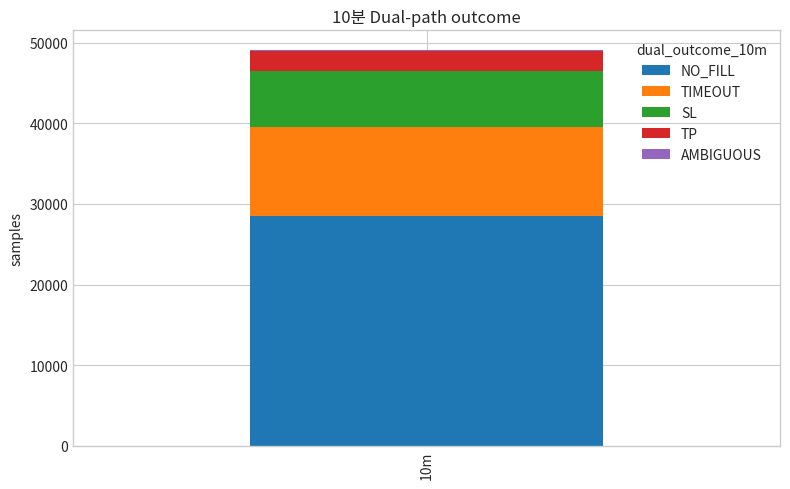

In [10]:
summary_rows = []
for horizon in HORIZONS:
    outcome = labels_df[f"dual_outcome_{horizon}m"]
    agreement = labels_df[f"dual_agreement_{horizon}m"]
    confirmed_target = labels_df.loc[agreement, f"target_tp_first_{horizon}m"]
    summary_rows.append({
        "horizon": horizon,
        "samples": len(labels_df),
        "agreement_share": agreement.mean(),
        "ambiguous": int((outcome == "AMBIGUOUS").sum()),
        "tp_confirmed": int((outcome == "TP").sum()),
        "sl_confirmed": int((outcome == "SL").sum()),
        "timeout_confirmed": int((outcome == "TIMEOUT").sum()),
        "no_fill_confirmed": int((outcome == "NO_FILL").sum()),
        "positive_share_among_confirmed": confirmed_target.mean(),
        "positive_share_given_fill": labels_df[f"target_tp_given_fill_{horizon}m"].mean(),
        "mean_expected_net_return": labels_df[f"expected_net_return_dual_{horizon}m"].mean(),
    })

horizon_summary_df = pd.DataFrame(summary_rows).set_index("horizon")
display(horizon_summary_df)

outcome_counts = pd.DataFrame({
    f"{horizon}m": labels_df[f"dual_outcome_{horizon}m"].value_counts()
    for horizon in HORIZONS
}).fillna(0).astype(int)
display(outcome_counts)
outcome_counts.T.plot.bar(stacked=True, figsize=(8, 5), title="10분 Dual-path outcome")
plt.ylabel("samples")
plt.tight_layout()
plt.show()


## 7. Primary 10분 라벨과 split 분포

In [11]:
primary_outcome = labels_df[f"dual_outcome_{PRIMARY_HORIZON}m"]
labels_df["primary_label_status"] = np.select(
    [primary_outcome.eq("TP"), primary_outcome.eq("AMBIGUOUS")],
    ["POSITIVE", "AMBIGUOUS"],
    default="NEGATIVE",
)
labels_df["binary_target_10m"] = labels_df["target_tp_first_10m"]
labels_df["binary_target_tp_given_fill_10m"] = labels_df["target_tp_given_fill_10m"]

primary_counts = pd.crosstab(labels_df["split"], labels_df["primary_label_status"], margins=True)
display(primary_counts)

confirmed_primary = labels_df[labels_df["primary_label_status"] != "AMBIGUOUS"]
split_label_summary = confirmed_primary.groupby("split").agg(
    samples=("binary_target_10m", "size"),
    positives=("binary_target_10m", "sum"),
    positive_share=("binary_target_10m", "mean"),
    symbols=("symbol", "nunique"),
    sessions=("session", "nunique"),
).reindex(["train", "validation", "test"])
display(split_label_summary)

filled_confirmed_primary = labels_df[labels_df["binary_target_tp_given_fill_10m"].notna()]
conditional_split_summary = filled_confirmed_primary.groupby("split").agg(
    filled_samples=("binary_target_tp_given_fill_10m", "size"),
    tp_first=("binary_target_tp_given_fill_10m", "sum"),
    tp_first_share_given_fill=("binary_target_tp_given_fill_10m", "mean"),
).reindex(["train", "validation", "test"])
display(Markdown("#### 체결 조건부 10분 target"))
display(conditional_split_summary)


primary_label_status,AMBIGUOUS,NEGATIVE,POSITIVE,All
split,,,,
test,16,14493,687,15196
train,35,21986,1240,23261
validation,21,9999,607,10627
All,72,46478,2534,49084


,samples,positives,positive_share,symbols,sessions
split,,,,,
train,23226,1240.0,0.053388,53,4
validation,10606,607.0,0.057232,26,2
test,15180,687.0,0.045257,36,3


#### 체결 조건부 10분 target

,filled_samples,tp_first,tp_first_share_given_fill
split,,,
train,9138,1240.0,0.135697
validation,4983,607.0,0.121814
test,6425,687.0,0.106926


## 8. 수수료와 진입 체결 영향

,value
order_attempts,49084.000000
filled_orders_high_first,20618.000000
fill_share,0.420055
mean_gross_return_when_filled,-0.004102
mean_net_return_when_filled,-0.006637
gross_positive_but_net_nonpositive,769.000000
mean_fee_drag,0.002536


#### 가격대별 tick 및 체결 proxy

,order_attempts,fill_share,min_reference_price,max_reference_price
tick_size,,,,
0.0001,15933,0.662022,0.0226,0.9997
0.0100,33151,0.303762,1.0000,26.9650


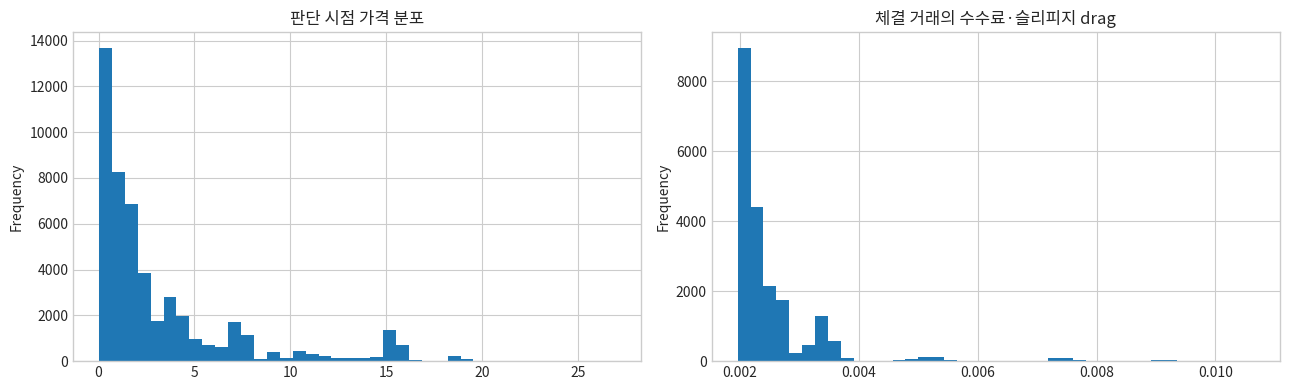

In [12]:
h = PRIMARY_HORIZON
filled_hf = labels_df[f"outcome_hf_{h}m"].ne("NO_FILL")
gross = labels_df.loc[filled_hf, f"gross_return_hf_{h}m"]
net = labels_df.loc[filled_hf, f"net_return_hf_{h}m"]
fee_impact = pd.Series({
    "order_attempts": len(labels_df),
    "filled_orders_high_first": int(filled_hf.sum()),
    "fill_share": filled_hf.mean(),
    "mean_gross_return_when_filled": gross.mean(),
    "mean_net_return_when_filled": net.mean(),
    "gross_positive_but_net_nonpositive": int(((gross > 0) & (net <= 0)).sum()),
    "mean_fee_drag": (gross - net).mean(),
}, name="value")
display(fee_impact.to_frame())

tick_fill_summary = (
    labels_df.assign(filled=filled_hf)
    .groupby("tick_size")
    .agg(
        order_attempts=("filled", "size"),
        fill_share=("filled", "mean"),
        min_reference_price=("reference_close", "min"),
        max_reference_price=("reference_close", "max"),
    )
)
display(Markdown("#### 가격대별 tick 및 체결 proxy"))
display(tick_fill_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels_df["reference_close"].plot.hist(bins=40, ax=axes[0], title="판단 시점 가격 분포")
(gross - net).plot.hist(bins=40, ax=axes[1], title="체결 거래의 수수료·슬리피지 drag")
plt.tight_layout()
plt.show()


## 9. 필수 무결성 검사

In [13]:
assert labels_df["entry_price"].gt(0).all()
assert labels_df["fill_threshold"].lt(labels_df["entry_price"]).all()
assert labels_df["take_profit_price"].gt(labels_df["entry_price"]).all()
assert labels_df["stop_loss_price"].lt(labels_df["entry_price"]).all()
assert labels_df["shares"].ge(1).all()
expected_tick_size = np.where(labels_df["reference_close"].lt(1.0), 0.0001, 0.01)
assert np.allclose(labels_df["tick_size"], expected_tick_size, rtol=0.0, atol=1e-12)
assert not any(any(token in column for token in ["_3m", "_5m", "_20m", "_30m"]) for column in labels_df.columns)
assert not {"volume", "vwap", "trade_count", "notional_usd"} & set(REQUIRED_COLUMNS)

valid_outcomes = {"TP", "SL", "TIMEOUT", "NO_FILL", "AMBIGUOUS"}
for horizon in HORIZONS:
    assert set(labels_df[f"dual_outcome_{horizon}m"].unique()) <= valid_outcomes
    agreement = labels_df[f"dual_agreement_{horizon}m"]
    assert labels_df.loc[~agreement, f"target_tp_first_{horizon}m"].isna().all()
    assert labels_df.loc[agreement, f"target_tp_first_{horizon}m"].notna().all()
    conditional_target = labels_df[f"target_tp_given_fill_{horizon}m"]
    assert conditional_target.dropna().isin([0.0, 1.0]).all()
    for short_name in ["hf", "lf"]:
        assert np.isfinite(labels_df[f"net_return_{short_name}_{horizon}m"]).all()

assert set(labels_df["split"]) == {"train", "validation", "test"}
assert labels_df.loc[labels_df["split"] == "train", "input_end_timestamp"].max() < labels_df.loc[labels_df["split"] == "validation", "input_end_timestamp"].min()
assert labels_df.loc[labels_df["split"] == "validation", "input_end_timestamp"].max() < labels_df.loc[labels_df["split"] == "test", "input_end_timestamp"].min()
print("PASS: 가격, outcome, ambiguous target, 순수익 및 시간 split 무결성 검사")


PASS: 가격, outcome, ambiguous target, 순수익 및 시간 split 무결성 검사


## 10. Phase 3 결론

In [14]:
PROCESSED_ROOT = DATA_ROOT / "processed"
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
LABELS_PATH = PROCESSED_ROOT / "labels_dual_path_10m_tp5_sl3_v2.parquet"
LABEL_SUMMARY_PATH = PROCESSED_ROOT / "labels_dual_path_10m_tp5_sl3_v2_summary.parquet"
labels_df.to_parquet(LABELS_PATH, index=False, compression="zstd")
horizon_summary_df.reset_index().to_parquet(LABEL_SUMMARY_PATH, index=False, compression="zstd")
print(f"saved: {LABELS_PATH} ({len(labels_df):,} rows)")

primary_agreement = labels_df["dual_agreement_10m"].mean()
primary_positive = confirmed_primary["binary_target_10m"].mean()
primary_positive_given_fill = filled_confirmed_primary["binary_target_tp_given_fill_10m"].mean()
findings = [
    "**목적 고정:** OHLC와 timestamp만 사용해 TP +5% / SL -3%의 10분 선도달 라벨만 생성했다.",
    f"**저장 완료:** `{LABELS_PATH}`에 라벨과 split metadata를 저장했다.",
    f"**라벨 가능 표본:** {total_feature_sequences:,}개 입력 sequence 중 미래 10분이 연속된 {len(labels_df):,}개에 10분 라벨을 생성했다.",
    f"**10분 확정성:** high-first와 low-first 결과 일치율은 {primary_agreement:.1%}다.",
    f"**10분 positive 비율:** ambiguous 제외 확정 표본 중 TP-first positive 비율은 {primary_positive:.1%}다.",
    f"**체결 조건부 positive 비율:** 체결된 확정 표본에서 10분 TP-first 비율은 {primary_positive_given_fill:.1%}다.",
    f"**체결률 proxy:** 첫 미래 봉 one-tick penetration 기준 체결 비율은 {float(fee_impact['fill_share']):.1%}다.",
    "**검증 통과:** 수수료, barrier 순서, NO_FILL, TIMEOUT, ambiguous 보존 및 시간 split 검사를 통과했다.",
    "**다음 단계:** 직접 order-success target과 `P(fill) × P(TP|fill)` 두 단계 방식을 모두 Gradient Boosting baseline에서 비교한다.",
]
display(Markdown("### 실행 결론\n\n" + "\n\n".join(f"- {item}" for item in findings)))


saved: /home/user/urbandatalab/YSLee/data/stock_data/processed/labels_dual_path_10m_tp5_sl3_v2.parquet (49,084 rows)


### 실행 결론

- **목적 고정:** OHLC와 timestamp만 사용해 TP +5% / SL -3%의 10분 선도달 라벨만 생성했다.

- **저장 완료:** `/home/user/urbandatalab/YSLee/data/stock_data/processed/labels_dual_path_10m_tp5_sl3_v2.parquet`에 라벨과 split metadata를 저장했다.

- **라벨 가능 표본:** 51,010개 입력 sequence 중 미래 10분이 연속된 49,084개에 10분 라벨을 생성했다.

- **10분 확정성:** high-first와 low-first 결과 일치율은 99.9%다.

- **10분 positive 비율:** ambiguous 제외 확정 표본 중 TP-first positive 비율은 5.2%다.

- **체결 조건부 positive 비율:** 체결된 확정 표본에서 10분 TP-first 비율은 12.3%다.

- **체결률 proxy:** 첫 미래 봉 one-tick penetration 기준 체결 비율은 42.0%다.

- **검증 통과:** 수수료, barrier 순서, NO_FILL, TIMEOUT, ambiguous 보존 및 시간 split 검사를 통과했다.

- **다음 단계:** 직접 order-success target과 `P(fill) × P(TP|fill)` 두 단계 방식을 모두 Gradient Boosting baseline에서 비교한다.

### 후속 구현 체크리스트

- [ ] fee, order, path evaluator를 `src/labels/` 모듈로 이동
- [ ] feature sequence index와 label metadata를 timestamp key로 결합
- [ ] boosting용 60봉 통계 요약 feature 생성
- [ ] train에서만 class weight와 scaler fit
- [ ] validation에서 calibration과 threshold 결정
- [ ] 수수료·slippage·tick size 민감도는 Phase 6에서 별도 비교
